# MVP Analítico: Modelagem Baseline
Objetivo: Treinamento e avaliação quantitativa do modelo preditivo baseline. Utilização de algoritmos ensemble (Random Forest) aplicados ao painel longitudinal H3, validando os resultados frente ao desbalanceamento de classes mediante métricas estatísticas de precisão.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import joblib
import os

sns.set_theme(style="whitegrid")


## 1. Carregando os Dados
Ingestão da base de dados padronizada, oriunda da etapa de pré-processamento.


In [12]:
data_path = '../data/SP/processed/painel_h3_semanal.csv'

try:
    df = pd.read_csv(data_path)
    print(f"Dados carregados: {df.shape}")
except FileNotFoundError:
    print("ERRO: O arquivo processado não foi encontrado. Execute o Notebook 02 primeiro.")
    df = pd.DataFrame()


Dados carregados: (105916, 4)


## 2. Preparando os Dados (Time-Based Split)
Implementação de Time-Based Split. Em modelagens com dimensão temporal, particionamentos estocásticos (como k-fold simples) introduzem vazamento de dados. A separação obedece à ordem cronológica.



In [13]:
if not df.empty:
    # Cria o painel completo (Hexágono x Semana) para gerar os ALVOS = 0 (sem crime)
    all_hex = df['H3_INDEX'].unique()
    all_weeks = df['ANO_SEMANA'].unique()
    full_grid = pd.MultiIndex.from_product([all_hex, all_weeks], names=['H3_INDEX', 'ANO_SEMANA']).to_frame(index=False)
    df = pd.merge(full_grid, df, on=['H3_INDEX', 'ANO_SEMANA'], how='left')
    df['ALVO'] = df['ALVO'].fillna(0)
    df['QTD_CRIMES'] = df['QTD_CRIMES'].fillna(0)
    
    df = df.sort_values('ANO_SEMANA')
    
    # ordem numérica da semana
    # A dimensão espacial é representada pela fatoração do identificador categórico H3
    df['SEMANA_NUM'] = df['ANO_SEMANA'].apply(lambda x: int(str(x).split('-')[1]))
    df['H3_CODE'] = df['H3_INDEX'].astype('category').cat.codes
    
    features = ['H3_CODE', 'SEMANA_NUM']
    target = 'ALVO'
    
    split_point = int(len(df) * 0.8)
    X_train = df[features].iloc[:split_point]
    y_train = df[target].iloc[:split_point]
    X_test = df[features].iloc[split_point:]
    y_test = df[target].iloc[split_point:]
    
    print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")
    print(f"Distribuição de Crimes no Treino:\n{y_train.value_counts().to_string()}")


Treino: (7806204, 2), Teste: (1951551, 2)
Distribuição de Crimes no Treino:
ALVO
0.0    7804727
1.0       1477


## 3. Treinando o Modelo (Regressão Logística & Random Forest)
Instanciação de classificador hierárquico (Random Forest Classifier). A configuração de hiperparâmetros (max_depth=5) é implementada para mitigar overfitting.


In [14]:
if not df.empty:
    model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1, class_weight='balanced')
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print("Baseline Model Treinado!")


Baseline Model Treinado!


## 4. Avaliação
Aferição do desempenho por meio de Matriz de Confusão e curva característica de operação do receptor (ROC-AUC).


--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

         0.0       0.96      0.68      0.79   1847112
         1.0       0.08      0.50      0.14    104439

    accuracy                           0.67   1951551
   macro avg       0.52      0.59      0.47   1951551
weighted avg       0.91      0.67      0.76   1951551

ROC-AUC: 0.6169


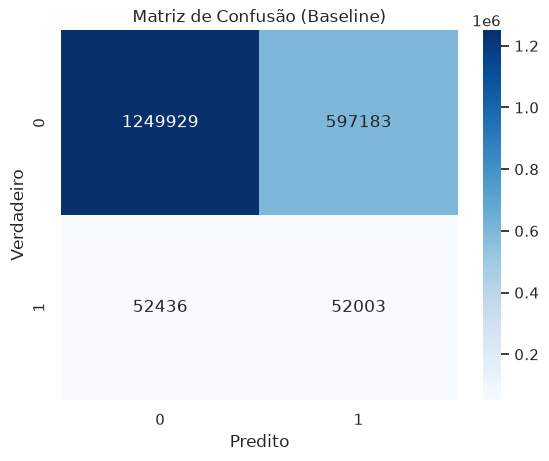

In [15]:
if not df.empty:
    print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
    print(classification_report(y_test, y_pred))
    
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC: {auc:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusão (Baseline)')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Predito')
    plt.show()


## 5. Exportando o Modelo


In [16]:
if not df.empty:
    os.makedirs('../models', exist_ok=True)
    joblib.dump(model, '../models/baseline.joblib')
    print("Modelo salvo em '../models/baseline.joblib' com sucesso!")


Modelo salvo em '../models/baseline.joblib' com sucesso!
